# Наивный классификатор качества DXA

Один **замороженный ResNet18 ImageNet** извлекает признаки DICOM. Для каждого из семи таргетов Excel независимо обучена линейная голова. Несколько кадров одной области внутри исследования объединяются средним вектором признаков. Метрики ниже рассчитаны по отложенным исследованиям в стратифицированных фолдах. Это базовая точка сравнения для следующих моделей, а не клиническая оценка.

Чтобы пересчитать обучение, установите `RETRAIN = True` во второй ячейке. Уже сохранённые признаки позволят повторить головы за несколько секунд. Если DICOM или метки изменились, признаки извлекутся снова.

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay

here = Path.cwd()
root = here if (here / 'dxa_project' / 'train_naive_resnet.py').exists() else here.parent
project = root / 'dxa_project'
if not (project / 'train_naive_resnet.py').exists():
    raise FileNotFoundError('Откройте ноутбук из корня Хакатон или папки dxa_project')
output = project / 'outputs' / 'naive_resnet18'

RETRAIN = False
if RETRAIN:
    python = root / '.venv' / 'Scripts' / 'python.exe'
    executable = str(python) if python.exists() else sys.executable
    subprocess.run([executable, str(project / 'train_naive_resnet.py')],
                   cwd=root, check=True)
print('Результаты:', output.resolve())


Результаты: C:\Users\Андрей\Desktop\Хакатон\dxa_project\outputs\naive_resnet18


## Результаты по семи целям

`AP` (average precision) сравнивайте с долей нарушений: при очень редких нарушениях она информативнее обычной accuracy. TP/FN/FP/TN вычислены на OOF прогнозах с фиксированным порогом 0,5.

In [2]:
metrics = pd.read_csv(output / 'metrics.csv')
predictions = pd.read_csv(output / 'study_oof_predictions.csv')
names = {
    'spine_position': 'Укладка позвоночника', 'spine_axis': 'Ось позвоночника',
    'spine_artifact': 'Артефакты позвоночника',
    'right_hip_rotation': 'Ротация правого бедра', 'right_hip_roi': 'ROI правого бедра',
    'left_hip_rotation': 'Ротация левого бедра', 'left_hip_roi': 'ROI левого бедра',
}
table = metrics.copy()
table.insert(0, 'Цель', table.task.map(names))
display(table[['Цель', 'n_studies', 'positives', 'tp', 'fn', 'fp', 'tn',
               'sensitivity', 'specificity', 'balanced_accuracy',
               'average_precision', 'prevalence']].round(3))


,Цель,n_studies,positives,tp,fn,fp,tn,sensitivity,specificity,balanced_accuracy,average_precision,prevalence
0,Укладка позвоночника,99,6,4,2,15,78,0.667,0.839,0.753,0.268,0.061
1,Ось позвоночника,99,10,0,10,28,61,0.000,0.685,0.343,0.079,0.101
2,Артефакты позвоночника,99,17,11,6,23,59,0.647,0.720,0.683,0.549,0.172
3,Ротация правого бедра,72,17,10,7,19,36,0.588,0.655,0.621,0.399,0.236
4,ROI правого бедра,72,3,2,1,16,53,0.667,0.768,0.717,0.712,0.042
5,Ротация левого бедра,78,19,8,11,29,30,0.421,0.508,0.465,0.260,0.244
6,ROI левого бедра,78,4,2,2,13,61,0.500,0.824,0.662,0.140,0.051


## Сравнение с простым ориентиром

Серая линия для balanced accuracy соответствует случайному ранжированию при бинарной классификации. На графике AP серые столбцы — доля нарушений в каждой задаче. Из-за 3–4 положительных исследований ROI оценка нестабильна.

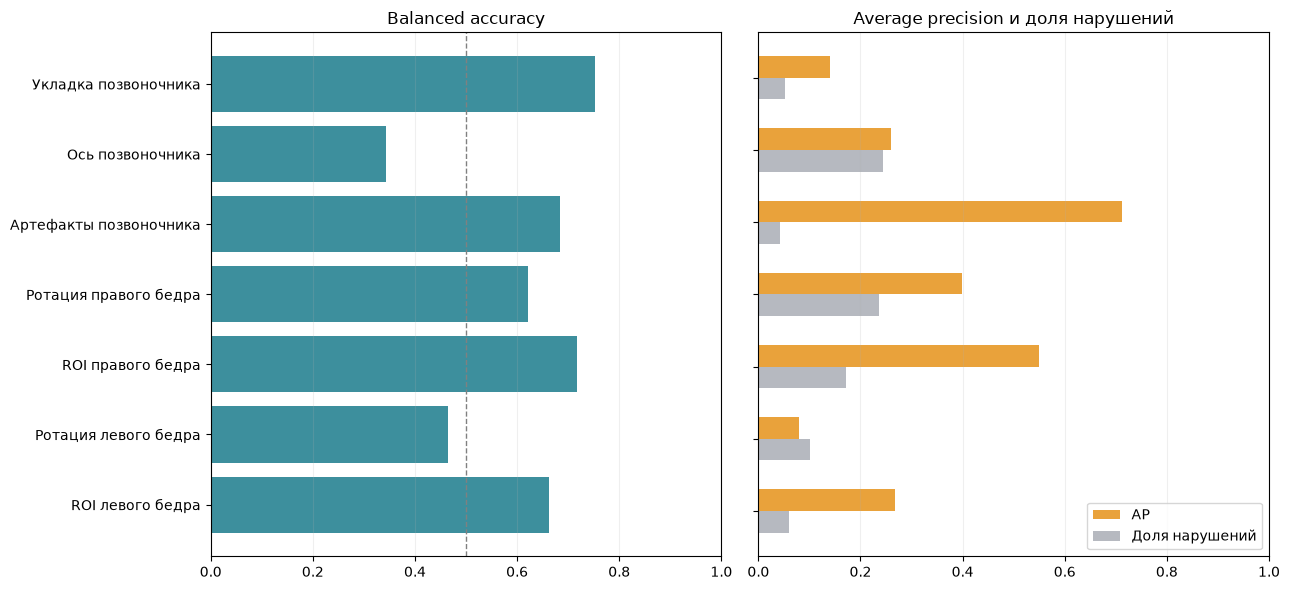

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
y = np.arange(len(metrics))
labels = [names[t] for t in metrics.task]
axes[0].barh(y, metrics.balanced_accuracy, color='#3d8f9d')
axes[0].axvline(.5, color='gray', linestyle='--', linewidth=1)
axes[0].set(xlim=(0, 1), title='Balanced accuracy')
axes[0].set_yticks(y, labels)
axes[0].invert_yaxis()
axes[1].barh(y + .15, metrics.average_precision, height=.3, label='AP', color='#e9a23b')
axes[1].barh(y - .15, metrics.prevalence, height=.3, label='Доля нарушений', color='#b6b9c0')
axes[1].set(xlim=(0, 1), title='Average precision и доля нарушений')
axes[1].tick_params(axis='y', labelleft=False)
axes[1].legend(loc='lower right')
for ax in axes:
    ax.grid(axis='x', alpha=.2)
fig.tight_layout()
plt.show()


## Матрицы ошибок

Строка — истинная метка, столбец — прогноз. Метка 1 означает нарушение качества. Для каждой задачи строки соответствуют исследованиям, а не отдельным DICOM кадрам.

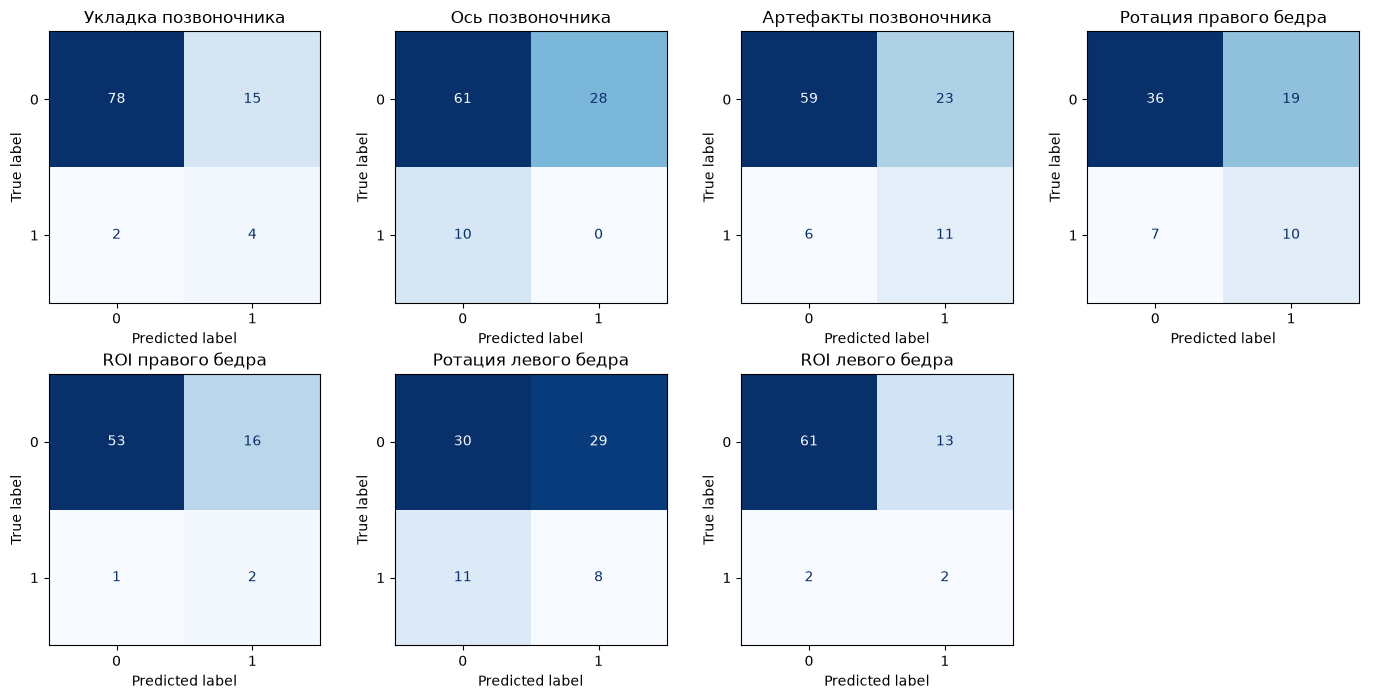

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, task in zip(axes.flat, metrics.task):
    rows = predictions[predictions.task.eq(task)]
    ConfusionMatrixDisplay.from_predictions(rows.target, rows.oof_prediction_05,
        labels=[0, 1], display_labels=['0', '1'], colorbar=False, cmap='Blues', ax=ax)
    ax.set_title(names[task])
for ax in list(axes.flat)[len(metrics):]:
    ax.axis('off')
fig.tight_layout()
plt.show()


## Ошибки и сомнительные случаи

Измените `task`, чтобы увидеть пропущенные нарушения и ложные тревоги. `oof_probability` — прогноз модели, которая не обучалась на метке данного исследования. В колонке `n_images` указано число кадров, объединённых в один прогноз.

In [5]:
task = 'spine_axis'
cases = predictions[predictions.task.eq(task)].copy()
cases['error'] = np.select(
    [(cases.target.eq(1) & cases.oof_prediction_05.eq(0)),
     (cases.target.eq(0) & cases.oof_prediction_05.eq(1))],
    ['FN', 'FP'], default='верно')
display(cases[cases.error.ne('верно')][[
    'reference_study_uid', 'region', 'n_images', 'target',
    'oof_probability', 'oof_prediction_05', 'error'
]].sort_values('oof_probability', ascending=False).head(40))


,reference_study_uid,region,n_images,target,oof_probability,oof_prediction_05,error
174,2.25.306921081709806079165809721263236241032,SPINE,1,0,0.879842,1,FP
178,2.25.322202456901330781765399791024580391565,SPINE,1,0,0.827545,1,FP
155,2.25.177745077805190810016231350557005569203,SPINE,2,0,0.813202,1,FP
138,2.25.157462338378550185821790046400986801350,SPINE,2,0,0.789826,1,FP
142,2.25.164566280810634620154538016595892212884,SPINE,1,0,0.788875,1,FP
102,2.25.10245777060263212829333021434108890537,SPINE,1,0,0.783539,1,FP
185,2.25.52532476139575422857225834315571570912,SPINE,1,0,0.779177,1,FP
149,2.25.172445998420765569384934552191547932566,SPINE,1,0,0.778527,1,FP
128,2.25.13566237352084812982996047541944701548,SPINE,1,0,0.766912,1,FP
114,2.25.124890633326693921702195356152595253940,SPINE,1,0,0.747328,1,FP


## Интерпретация

Укладка позвоночника и артефакты дали лучший стартовый результат. Ось позвоночника и ротация левого бедра пока не решаются этим простым классификатором убедительно. Для правого ROI всего три положительных исследования; показатель AP нельзя считать устойчивым. Порог 0,5 был зафиксирован заранее. Подробный метод и ограничения — в `dxa_project/NAIVE_RESNET_RESULTS.md`. Модели семи голов сохранены в `outputs/naive_resnet18/*.joblib`.